# Identifying a spatial code of ligand-receptor pairs with a genetic algorithm

Cells that sit close together in a tissue should be talking to each other — but only some of the
ligand-receptor pairs in a resource carry that spatial signal, and the rest dilute it. This tutorial
searches for the subset whose cell-cell interaction scores best reproduce **how far apart the cells
actually are**, using a genetic algorithm.

The pairs it recovers are a *spatial code*: the interactions whose activity tracks physical
proximity, and which can therefore be read as a signature of where cells are relative to one another.

The method is that of
[Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715) on the whole body of
*C. elegans*, available as `cell2cell.analysis.optimize_lr_pairs`. This notebook uses **synthetic
data where the answer is known in advance**, so the search can be judged. Two companions:

- [Reproducing the *C. elegans* spatial code](./Celegans-Spatial-Code) runs the published analysis
  on the real data and compares against the pairs the paper reports.
- [Customizing the objective function](./Custom-Objective-Functions) covers optimizing something
  other than a single dataset's distance correlation.

The reference does not have to be a physical distance — any square matrix of distances between the
same cells works, so the same search applies to developmental, functional or phenotypic similarity.
Here we start from spatial transcriptomics, using the helpers that turn single-cell coordinates into
cell-type distances, and finish on the *C. elegans* 3D map.

**Requirements.** The genetic algorithm needs the optional dependency `pygad`:

```
pip install cell2cell[ga]
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cell2cell as c2c

%matplotlib inline

/private/tmp/claude-503/-Users-eg22-Repos-cell2cell/fa1914c8-fe56-40d2-b837-7db6feb472f8/scratchpad/venv-ci312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

We build a small synthetic system where we know the answer in advance, so the search can be judged.

Twelve cell types sit at different positions along an axis. Around each one we scatter single cells,
which is what a spatial transcriptomics experiment would give us.

In [2]:
import anndata

rng = np.random.default_rng(0)

n_celltypes = 12
cells_per_type = 40
positions = np.linspace(0, 100, n_celltypes)
celltypes = ['CT-{}'.format(i + 1) for i in range(n_celltypes)]

coords, labels = [], []
for name, x in zip(celltypes, positions):
    coords.append(np.column_stack([rng.normal(x, 2.5, cells_per_type),
                                   rng.normal(0, 2.5, cells_per_type)]))
    labels += [name] * cells_per_type

coords = np.vstack(coords)
adata = anndata.AnnData(X=np.zeros((len(coords), 1), dtype=float),
                        obs=pd.DataFrame({'celltype': labels},
                                         index=['cell-{}'.format(i) for i in range(len(coords))]))
adata.obsm['spatial'] = coords
adata

AnnData object with n_obs × n_vars = 480 × 1
    obs: 'celltype'
    obsm: 'spatial'
    layers: None (.X)

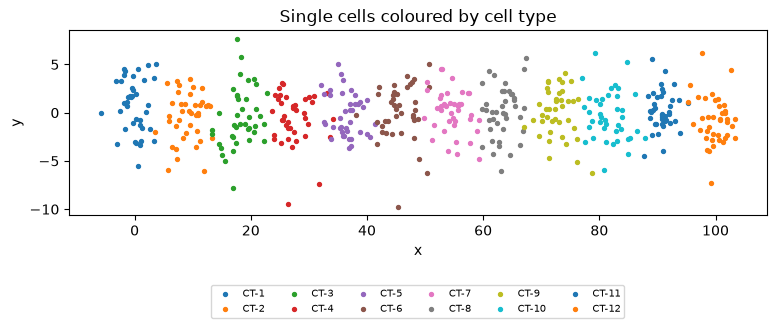

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.4))
for name in celltypes:
    mask = adata.obs['celltype'] == name
    ax.scatter(adata.obsm['spatial'][mask, 0], adata.obsm['spatial'][mask, 1], s=8, label=name)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Single cells coloured by cell type')
ax.legend(ncol=6, fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.35))
plt.show()

### Gene expression

Half of the ligand-receptor pairs are **informative**: the expression of their ligand and receptor
follows a bump centred somewhere along the axis, so cell types close to each other co-express them.
The other pairs are **noise**, with expression unrelated to position.

A perfect search would keep the informative pairs and drop the rest.

In [4]:
n_informative, n_noise = 12, 48

genes, profiles, pairs = [], [], []
informative_centres = rng.uniform(0, 100, n_informative)   # kept for section 6

for k in range(n_informative):
    centre = informative_centres[k]
    bump = 200 * np.exp(-((positions - centre) ** 2) / (2 * 22.0 ** 2))
    for tag in ('L', 'R'):
        genes.append('{}info{}'.format(tag, k))
        profiles.append(bump * rng.uniform(0.8, 1.2, n_celltypes))
    pairs.append(('Linfo{}'.format(k), 'Rinfo{}'.format(k)))

for k in range(n_noise):
    for tag in ('L', 'R'):
        genes.append('{}noise{}'.format(tag, k))
        profiles.append(rng.uniform(0, 200, n_celltypes))
    pairs.append(('Lnoise{}'.format(k), 'Rnoise{}'.format(k)))

rnaseq = pd.DataFrame(np.vstack(profiles), index=genes, columns=celltypes)
lr_pairs = pd.DataFrame(pairs, columns=['A', 'B'])

print('expression :', rnaseq.shape)
print('LR pairs   :', lr_pairs.shape[0], '({} informative, {} noise)'.format(n_informative, n_noise))
rnaseq.iloc[:4, :6].round(1)

expression : (120, 12)
LR pairs   : 60 (12 informative, 48 noise)


,CT-1,CT-2,CT-3,CT-4,CT-5,CT-6
Linfo0,203.1,165.8,179.9,130.3,96.3,46.2
Rinfo0,161.2,163.5,171.1,124.4,82.6,58.6
Linfo1,89.0,144.3,181.4,165.1,215.2,146.7
Rinfo1,87.3,152.3,177.2,189.7,170.9,139.9


## 2. Reference distances from the single-cell coordinates

`cell2cell.spatial.celltype_distances` summarizes the distance between two cell types from the
coordinates of their single cells. It takes an `AnnData` (reading `obsm`) or a plain dataframe, and
offers several ways to summarize:

| `method` | what it measures |
|---|---|
| `'centroid'` | distance between the centroids of the two cell types |
| `'min'` | how close the two types get to each other |
| `'max'` | how far apart their most distant cells are |
| `'mean'` / `'median'` | average / median over all pairs of their single cells |

Only `'centroid'` has a cost independent of how many single cells there are, so it is the one to
reach for on large datasets — the others evaluate all pairs of cells.

The key holding the coordinates is configurable with `spatial_key`, since objects written by
different tools use different ones (`'spatial'`, `'X_spatial'`, ...).

In [5]:
centroids = c2c.spatial.celltype_centroids(adata, group_col='celltype', spatial_key='spatial')
centroids.round(2).head()

,X,Y
celltype,,
CT-1,-0.15,0.75
CT-2,9.10,-0.42
CT-3,18.19,-0.53
CT-4,27.41,-0.61
CT-5,36.45,-0.19


In [6]:
for method in ['centroid', 'min', 'mean', 'median', 'max']:
    d = c2c.spatial.celltype_distances(adata, group_col='celltype', method=method)
    print('{:<9} CT-1 to CT-12 = {:6.2f}'.format(method, d.loc['CT-1', 'CT-12']))

centroid  CT-1 to CT-12 = 100.01
min       CT-1 to CT-12 =  91.64
mean      CT-1 to CT-12 = 100.08
median    CT-1 to CT-12 = 100.16
max       CT-1 to CT-12 = 109.19


In [7]:
reference_distances = c2c.spatial.celltype_distances(adata, group_col='celltype',
                                                     method='centroid')
reference_distances.iloc[:5, :5].round(1)

celltype,CT-1,CT-2,CT-3,CT-4,CT-5
celltype,,,,,
CT-1,0.0,9.3,18.4,27.6,36.6
CT-2,9.3,0.0,9.1,18.3,27.3
CT-3,18.4,9.1,0.0,9.2,18.3
CT-4,27.6,18.3,9.2,0.0,9.0
CT-5,36.6,27.3,18.3,9.0,0.0


## 3. The baseline: using every ligand-receptor pair

Before searching, we measure how well the CCI distances reproduce the reference when *all* pairs are
used. The genetic algorithm has to beat this.

The objective is the absolute **Spearman** correlation between the two distance matrices, in their
condensed (upper-triangle) form.

In [8]:
import scipy.spatial
from cell2cell.analysis import correlation_fitness
from cell2cell.core import PreparedCCIScorer
from cell2cell.preprocessing import bidirectional_index
from cell2cell.core.interaction_space import InteractionSpace

analysis_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'bray_curtis',
                  'cci_type': 'undirected'}
cutoff_setup = {'type': 'constant_value', 'parameter': 50}

bi_ppi = c2c.preprocessing.bidirectional_ppi_for_cci(lr_pairs, verbose=False)
interaction_space = InteractionSpace(rnaseq_data=rnaseq, ppi_data=bi_ppi,
                                     gene_cutoffs=cutoff_setup,
                                     communication_score=analysis_setup['communication_score'],
                                     cci_score=analysis_setup['cci_score'],
                                     cci_type=analysis_setup['cci_type'], verbose=False)

scorer = PreparedCCIScorer(interaction_space)
source = bidirectional_index(lr_pairs, verbose=False)

reference_vector = scipy.spatial.distance.squareform(reference_distances.values, checks=False)
all_pairs = np.ones(len(lr_pairs))
baseline_distance = scorer.distance_batch(all_pairs[source][None, :])[0]
baseline = correlation_fitness(scipy.spatial.distance.squareform(baseline_distance, checks=False),
                        reference_vector)

print('Spearman correlation using all {} pairs: {:.4f}'.format(len(lr_pairs), baseline))

Spearman correlation using all 60 pairs: 0.7677


## 4. Running the genetic algorithm

Each individual is a binary vector with one entry per ligand-receptor pair, saying whether it is
included. `optimize_lr_pairs` evolves a population of these and keeps the best.

The search happens in successive **runs**: each run keeps only the pairs the previous one selected,
so the set shrinks. With `runs=None` it stops once the objective improves by less than
`inc_percentage`.

In [9]:
results = c2c.analysis.optimize_lr_pairs(rnaseq_data=rnaseq,
                                         ppi_data=lr_pairs,
                                         reference_distances=reference_distances,
                                         cutoff_setup=cutoff_setup,
                                         analysis_setup=analysis_setup,
                                         population_size=60,
                                         generations=40,
                                         runs=3,
                                         random_state=888)

summary = pd.DataFrame([{'run': k,
                         'objective': results[k]['obj_fn'],
                         'pairs kept': results[k]['n_selected'],
                         'dropped': '{:.0%}'.format(results[k]['drop_fraction'])}
                        for k in sorted(results) if k.startswith('run')])
summary

,run,objective,pairs kept,dropped
0,run1,0.952765,24,60%
1,run2,0.971133,17,29%
2,run3,0.971133,17,0%


Every run improves on the baseline, and the set of pairs shrinks as it goes.

Because we know which pairs were informative, we can check *what* the search recovered.

In [10]:
for key in sorted(k for k in results if k.startswith('run')):
    kept = lr_pairs.loc[np.asarray(results[key]['ppi_data'], dtype=bool)]
    informative = kept['A'].str.startswith('Linfo').mean()
    print('{}: objective {:.4f} | {:>2} pairs kept | {:.0%} of them informative'
          .format(key, results[key]['obj_fn'], len(kept), informative))

best = results['best_ppi_data']
print('\nBest run:', results['best_run'], '-> objective {:.4f}'.format(results['best_obj_fn']))
best

run1: objective 0.9528 | 24 pairs kept | 46% of them informative
run2: objective 0.9711 | 17 pairs kept | 53% of them informative
run3: objective 0.9711 | 17 pairs kept | 53% of them informative

Best run: run2 -> objective 0.9711


,A,B
0,Linfo0,Rinfo0
1,Linfo1,Rinfo1
2,Linfo11,Rinfo11
3,Linfo2,Rinfo2
4,Linfo3,Rinfo3
5,Linfo5,Rinfo5
6,Linfo6,Rinfo6
7,Linfo8,Rinfo8
8,Linfo9,Rinfo9
9,Lnoise0,Rnoise0


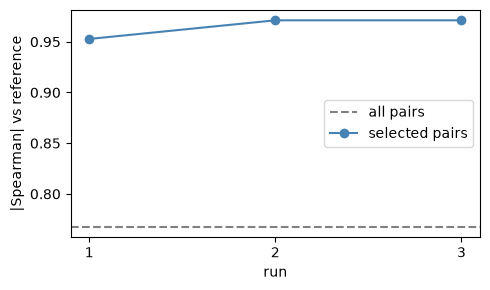

In [11]:
runs = sorted(k for k in results if k.startswith('run'))
objectives = [results[k]['obj_fn'] for k in runs]

fig, ax = plt.subplots(figsize=(5, 3))
ax.axhline(baseline, color='grey', ls='--', label='all pairs')
ax.plot(range(1, len(runs) + 1), objectives, 'o-', color='steelblue', label='selected pairs')
ax.set_xlabel('run'); ax.set_ylabel('|Spearman| vs reference')
ax.set_xticks(range(1, len(runs) + 1)); ax.legend()
plt.tight_layout(); plt.show()

### How the distances line up

Plotting the CCI distances against the reference shows what the search bought.

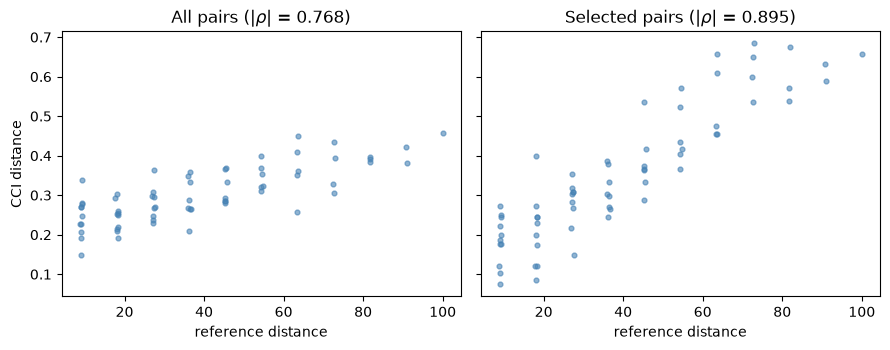

In [12]:
best_mask = np.zeros(len(lr_pairs))
best_mask[np.asarray(results[results['best_run']]['ppi_data'], dtype=bool)] = 1.0
best_distance = scorer.distance_batch(best_mask[source][None, :])[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for ax, matrix, title in zip(axes, [baseline_distance, best_distance],
                             ['All pairs', 'Selected pairs']):
    vector = scipy.spatial.distance.squareform(matrix, checks=False)
    rho = correlation_fitness(vector, reference_vector)
    ax.scatter(reference_vector, vector, s=12, alpha=0.6, color='steelblue')
    ax.set_title('{} ($|\\rho|$ = {:.3f})'.format(title, rho))
    ax.set_xlabel('reference distance')
axes[0].set_ylabel('CCI distance')
plt.tight_layout(); plt.show()

## 5. Why this is fast

Rebuilding the CCI scores for every individual would be far too slow: the published analysis used a
population of 200 over 200 generations, i.e. **40,000 evaluations per run**.

`PreparedCCIScorer` avoids that. Every CCI score is a function of three quantities that are each a
weighted sum over the ligand-receptor pairs, and therefore **linear in the pair weights** `w`:

```
N(i, j) = sum_k w_k * A_ki * B_kj        SA(i) = sum_k w_k * A_ki^2
                                         SB(j) = sum_k w_k * B_kj^2

bray_curtis = 2N / (SA + SB)      jaccard = N / (SA + SB - N)      icellnet = N
```

`A` and `B` depend only on the expression data, which does not change during the search. So they are
computed once, and scoring a whole population becomes a single matrix multiplication.

This is used automatically. `fast=False` falls back to rebuilding the scores through
`InteractionSpace`, exactly as the original implementation did — the two give the same answer.

In [13]:
import time

rng_check = np.random.default_rng(0)
population = rng_check.integers(0, 2, size=(200, len(lr_pairs))).astype(float)

start = time.perf_counter()
batched = scorer.score_batch(population[:, source])
t_batched = time.perf_counter() - start

start = time.perf_counter()
one_at_a_time = np.stack([scorer.score_batch(w[source][None, :])[0] for w in population])
t_single = time.perf_counter() - start

print('whole population at once : {:.4f} s'.format(t_batched))
print('one individual at a time : {:.4f} s'.format(t_single))
print('identical                :', np.allclose(batched, one_at_a_time, rtol=1e-12, atol=1e-12))

whole population at once : 0.0004 s
one individual at a time : 0.0042 s
identical                : True


In [14]:
# ...and the vectorized scorer agrees with the reference implementation
theta = rng_check.integers(0, 2, size=len(lr_pairs)).astype(float)
weights = theta[source]

interaction_space.ppi_data['score'] = weights
interaction_space.compute_pairwise_cci_scores(use_ppi_score=True, verbose=False)
expected = interaction_space.interaction_elements['cci_matrix'].values

print('largest difference vs InteractionSpace: {:.2e}'
      .format(np.abs(scorer.score_batch(weights[None, :])[0] - expected).max()))

largest difference vs InteractionSpace: 0.00e+00


## 6. Several datasets at once

Everything so far used one dataset. In practice there are usually several — slides, donors,
conditions — and a genetic algorithm converges to a *local* optimum, so a set fitted to one of them
is partly fitted to its noise.

With ~20 cell types the objective has only `20 × 19 / 2 = 190` points, while the search has ~60
binary variables to fit them with. That is a lot of freedom, and the way to remove it is to demand
the same set work everywhere.

We build three "donors": the same planted spatial code, measured with independent noise.

In [15]:
def make_donor(seed):
    """The same informative pairs, re-measured with independent noise."""
    rng_d = np.random.default_rng(seed)
    profiles = []
    for k in range(n_informative):
        centre = informative_centres[k]
        bump = 200 * np.exp(-((positions - centre) ** 2) / (2 * 22.0 ** 2))
        for _ in ('L', 'R'):
            profiles.append(bump * rng_d.uniform(0.8, 1.2, n_celltypes))
    for _ in range(n_noise):
        for _ in ('L', 'R'):
            profiles.append(rng_d.uniform(0, 200, n_celltypes))
    donor = pd.DataFrame(np.vstack(profiles), index=genes, columns=celltypes)

    jitter = coords + rng_d.normal(0, 1.5, coords.shape)
    donor_adata = anndata.AnnData(X=np.zeros((len(jitter), 1)), obs=adata.obs.copy())
    donor_adata.obsm['spatial'] = jitter
    donor_ref = c2c.spatial.celltype_distances(donor_adata, group_col='celltype', method='centroid')
    return donor, donor_ref

donors = [make_donor(seed) for seed in (101, 202, 303)]
print('three donors, each {} genes x {} cell types'.format(*donors[0][0].shape))

three donors, each 120 genes x 12 cell types


### One search per donor: the selections disagree

In [16]:
def informative_fraction(selected):
    return selected['A'].str.startswith('Linfo').mean() if len(selected) else 0.0

# Settings that do not depend on the objective. `cutoff_setup` and `analysis_setup`
# are deliberately kept out: passing them alongside an `objective` is rejected,
# because the objective already carries them.
search = dict(ppi_data=lr_pairs, population_size=60, generations=40,
              runs=2, random_state=888)
setups = dict(cutoff_setup=cutoff_setup, analysis_setup=analysis_setup)

per_donor = []
for i, (donor_rnaseq, donor_ref) in enumerate(donors, start=1):
    r = c2c.analysis.optimize_lr_pairs(rnaseq_data=donor_rnaseq,
                                       reference_distances=donor_ref, **setups, **search)
    kept = r['best_ppi_data']
    per_donor.append(set(map(tuple, kept[['A', 'B']].values)))
    print('donor {}: objective {:.3f} | {:>2} pairs | {:.0%} informative'
          .format(i, r['best_obj_fn'], len(kept), informative_fraction(kept)))

shared = set.intersection(*per_donor)
print('\npairs selected by all three donors: {} of {}'
      .format(len(shared), len(set.union(*per_donor))))

donor 1: objective 0.970 |  8 pairs | 88% informative


donor 2: objective 0.968 | 13 pairs | 77% informative


donor 3: objective 0.957 | 19 pairs | 47% informative

pairs selected by all three donors: 5 of 26


### Pooling the objective instead

`CombinedObjective` evaluates one candidate against every donor and combines the result, so the
search is driven towards pairs that work everywhere. The same ~60 variables now face `3 × 190`
constraints rather than 190.

In [17]:
factories = [c2c.analysis.CorrelationObjective(rnaseq_data=donor_rnaseq,
                                               reference_distances=donor_ref,
                                               cutoff_setup=cutoff_setup,
                                               analysis_setup=analysis_setup)
             for donor_rnaseq, donor_ref in donors]

pooled = c2c.analysis.optimize_lr_pairs(
    objective=c2c.analysis.CombinedObjective(factories), **search)

kept = pooled['best_ppi_data']
print('pooled across 3 donors: objective {:.3f} | {:>2} pairs | {:.0%} informative'
      .format(pooled['best_obj_fn'], len(kept), informative_fraction(kept)))

pooled across 3 donors: objective 0.952 | 10 pairs | 90% informative


### Penalising disagreement

`sd_penalty` subtracts a multiple of the standard deviation across donors, so a set that is
uniformly decent is preferred over one that is excellent on some donors and poor on others.
`evaluate_components` reports the per-donor fitness of a solution, which the combined number alone
cannot tell you.

In [18]:
pool = pooled['pool']

def per_donor_fitness(mask, penalty=0.0):
    bound = c2c.analysis.CombinedObjective(factories, sd_penalty=penalty)(pool)
    return bound.evaluate_components(np.atleast_2d(np.asarray(mask, dtype=float)))[:, 0]

penalised = c2c.analysis.optimize_lr_pairs(
    objective=c2c.analysis.CombinedObjective(factories, sd_penalty=1.0), **search)

for label, res in (('no penalty', pooled), ('sd_penalty=1.0', penalised)):
    components = per_donor_fitness(res[res['best_run']]['ppi_data'])
    print('{:<16} per-donor rho {}  mean {:.3f}  sd {:.3f}  | {:.0%} informative'
          .format(label, np.round(components, 3), components.mean(), components.std(),
                  informative_fraction(res['best_ppi_data'])))

no penalty       per-donor rho [0.959 0.956 0.941]  mean 0.952  sd 0.008  | 90% informative
sd_penalty=1.0   per-donor rho [0.944 0.944 0.943]  mean 0.944  sd 0.001  | 75% informative


### Leave-one-donor-out

The check most worth doing, and the one most often skipped. Select on two donors, evaluate on the
third. If the selected set does not beat a random set of the same size *out of sample*, it fitted
noise — and with 190 points per donor that is a live possibility rather than a formality.

In [19]:
rng_lodo = np.random.default_rng(0)

for held_out in range(3):
    train = [f for i, f in enumerate(factories) if i != held_out]
    fitted = c2c.analysis.optimize_lr_pairs(
        objective=c2c.analysis.CombinedObjective(train), **search)

    mask = np.asarray(fitted[fitted['best_run']]['ppi_data'], dtype=float)
    test = factories[held_out](fitted['pool'])
    selected = test(mask[None, :])[0]

    sizes = int(mask.sum())
    random_masks = np.zeros((100, len(mask)))
    for row in random_masks:
        row[rng_lodo.choice(len(mask), sizes, replace=False)] = 1.0
    random_scores = test(random_masks)

    print('held-out donor {}: selected {:.3f} | random sets of {} {:.3f} +/- {:.3f} | all pairs {:.3f}'
          .format(held_out + 1, selected, sizes, random_scores.mean(), random_scores.std(),
                  test(np.ones((1, len(mask))))[0]))

held-out donor 1: selected 0.924 | random sets of 14 0.370 +/- 0.189 | all pairs 0.722


held-out donor 2: selected 0.956 | random sets of 10 0.500 +/- 0.172 | all pairs 0.782


held-out donor 3: selected 0.937 | random sets of 8 0.394 +/- 0.211 | all pairs 0.811


The held-out score should sit clearly above random sets of the same size. If it does not, the
selection is not carrying signal that generalises, whatever the training objective says.

---

Next: [reproducing the *C. elegans* spatial code](./Celegans-Spatial-Code) on real data, or
[customizing the objective function](./Custom-Objective-Functions).